In [1]:
%%time
%matplotlib inline

import importlib
import new_import_ODC  

importlib.reload(new_import_ODC)

from new_import_ODC import *

CPU times: user 8.65 s, sys: 6.03 s, total: 14.7 s
Wall time: 8.59 s


In [2]:
%%time
# Cấu hình Daskgateway
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1, 10))
# Khai báo 1 Datacube là dc
dc = datacube.Datacube()

# Cấu hình truy cập dịch vụ S3
configure_s3_access(aws_unsigned=False, requester_pays=True, client=client)

client

Starting new cluster.
CPU times: user 595 ms, sys: 46.3 ms, total: 641 ms
Wall time: 3min 55s


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.127ae1e5b0de4184b0adf8062163f7df/status,


In [3]:
## cấu hình thời gian lấy ảnh và tọa độ
date_range = ("2022-09-01", "2023-10-01")
longtitude_range = (105.5, 106.4)
latitude_range = (9.2, 10.0)

coordinates = (longtitude_range, latitude_range)

In [4]:
## truy vấn ảnh vệ tinh sen2
data = load_data(dc, date_range, longtitude_range, latitude_range)
notebook_utils.heading(notebook_utils.xarray_object_size(data))
display(data)

Most common native CRS: EPSG:32648
No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 119GB
Dimensions:      (time: 151, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    red          (time, y, x) float32 53GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 53GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 13GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [5]:
%%time
# Tiến hành loại bỏ các vị trí bị mây ảnh hưởng
result = mask_clean(data)
progress(result)

,bits,values,description
qa,"[0, 1, 2, 3, 4, 5, 6, 7]","{'0': 'no data', '1': 'saturated or defective'...",Sen2Cor Scene Classification


{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

CPU times: user 1.21 s, sys: 20.7 ms, total: 1.23 s
Wall time: 1.23 s


VBox()

In [6]:
# Tiến hành tính toán NDVI
ds1 = calculate_indices(result, index="NDVI", satellite_mission="s2")
ndvi = ds1["NDVI"]
display(ndvi)

<xarray.DataArray 'NDVI' (time: 151, y: 8874, x: 9902)> Size: 53GB
dask.array<truediv, shape=(151, 8874, 9902), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648

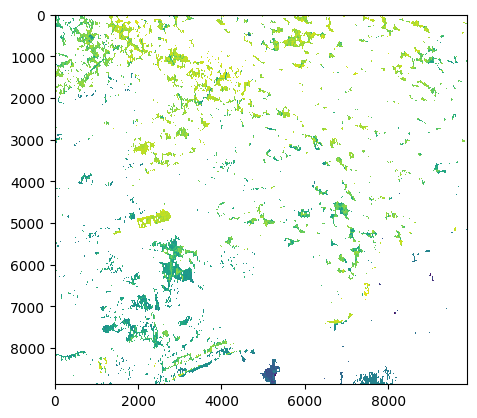

In [7]:
## Hiển thị ảnh NDVI chưa điền các giá trị mây (chưa fill nan)
plt.imshow(ndvi.isel(time=6))

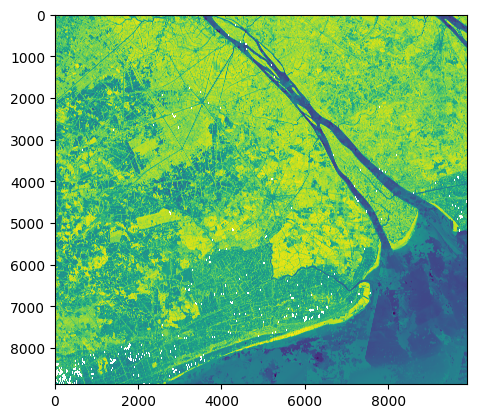

In [8]:
# Thiết lập giá trị trung bình mùa vụ để xử lý các điểm ảnh bị mây dựa vào sự thay đổi theo mùa
time_split = [
    slice("2022-09-01", "2023-01-01"),
    slice("2023-01-01", "2023-05-01"),
    slice("2023-05-01", "2023-07-01"),
    slice("2023-07-01", "2023-10-01"),
]

# Điền mây ở các vị trí mang giá trị nan (fill nan)
fill_nan_ndvi = fill_nan(ndvi, time_split)

# In kết quả ảnh NDVI đã điền mây (đã fill nan)
plt.imshow(fill_nan_ndvi.isel(time=6))

In [9]:
%%time
## tính ndvi theo tháng
average_ndvi = fill_nan_ndvi.resample(time="1M").mean().persist()
progress(average_ndvi)

# compute average_ndvi
average_ndvi = average_ndvi.compute()

<string>:6: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


CPU times: user 7.19 s, sys: 3.26 s, total: 10.5 s
Wall time: 4min 16s


In [10]:
#Load dữ liệu ảnh Sentinel 1
dsvh, dsvv = load_data_sen1(dc, date_range, coordinates)
average_vv = calculate_average(dsvv, time_pattern='1M')
average_vh = calculate_average(dsvh, time_pattern='1M')

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 33, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 264B 2022-09-06T22:46:14.500000 ... 20...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    vv           (time, y, x) float32 12GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    vh           (time, y, x) float32 12GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

<string>:6: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.
<string>:6: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


In [11]:
## cấu hình bộ dữ liệu điểm huấn luyện mô hình (train file)
train_path = "train/ST_training data_updated_1130points_new.shp"  # đường dẫn shp file train

## load dữ liệu điểm huấn luyện mô hình (train file)
train = load_train_data(train_path)
train.head()

# cấu hình nhãn dữ liệu 
label_mapping = {
    "Lua tom": "0",
    "Lua": "1",
    "CHN": "2",
    "CLN": "3",
    "TS": "4",
    "Song": "5",
    "Dat xay dung": "6",
    "Rung": "7",
}

# xây dựng tập dữ liệu (dataset) chứa dữ liệu VH, VV, NDVI
datasets = get_data_sen1_and_sen2(train, average_ndvi, average_vh, average_vv)

# chia tập dữ liệu thành các phần theo tỉ lệ 80(80-20)-20 tương ứng với tập train, validate, test
X_train, X_val, X_test, y_train, y_val, y_test = split_train_data(
    train, label_mapping, datasets
)

In [ ]:
%%time
# Import XGBoost
import xgboost as xgb
from sklearn.metrics import accuracy_score
import numpy as np

# Convert to numpy arrays
X_train_np = np.asarray(X_train, dtype=np.float32)
X_val_np = np.asarray(X_val, dtype=np.float32)
y_train_np = np.asarray(y_train, dtype=np.int32)
y_val_np = np.asarray(y_val, dtype=np.int32)

print("🚀 Training XGBoost model...")
print(f"   Train samples: {len(X_train_np)}")
print(f"   Val samples: {len(X_val_np)}")
print(f"   Features: {X_train_np.shape[1]}")
print(f"   Classes: 8\n")

# XGBoost parameters
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': 8,                 # 8 land use classes
    'max_depth': 6,                 # Maximum tree depth
    'learning_rate': 0.1,           # Learning rate
    'n_estimators': 200,            # Number of trees
    'subsample': 0.8,               # Subsample ratio
    'colsample_bytree': 0.8,        # Feature sampling ratio
    'random_state': 42,
    'n_jobs': -1,                   # Use all CPU cores
    'eval_metric': 'mlogloss'       # Multi-class log loss
}

# Train XGBoost model
model = xgb.XGBClassifier(**params)

model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_train_np, y_train_np), (X_val_np, y_val_np)],
    verbose=True
)

# Validation accuracy
y_val_pred = model.predict(X_val_np)
val_accuracy = accuracy_score(y_val_np, y_val_pred)
print(f"\n✅ Training completed!")
print(f"   Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

Best Parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'classifier__n_estimators': 300}
Accuracy: 89.0 %


In [ ]:
%%time
# Evaluate on test set
X_test_np = np.asarray(X_test, dtype=np.float32)
y_test_np = np.asarray(y_test, dtype=np.int32)

print("📊 Evaluating XGBoost model on test set...\n")

# Predictions
y_pred_test = model.predict(X_test_np)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

test_accuracy = accuracy_score(y_test_np, y_pred_test)
precision = precision_score(y_test_np, y_pred_test, average='weighted', zero_division=0)
recall = recall_score(y_test_np, y_pred_test, average='weighted', zero_division=0)
f1 = f1_score(y_test_np, y_pred_test, average='weighted', zero_division=0)

print(f"📈 Test Results:")
print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}\n")

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create figure first
fig, ax = plt.subplots(figsize=(10, 8))

class_names = list(label_mapping.keys())
cm = confusion_matrix(y_test_np, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

Accuracy for test data 90.0 %


In [ ]:
# Lưu mô hình huấn luyện
import json
import joblib

# Save XGBoost model
model_path = "model_xgboost.joblib"
joblib.dump(model, model_path)
print(f"✅ Model saved to {model_path}")

# Save model info
info = {
    "model_type": "XGBoost",
    "num_classes": 8,
    "classes": list(label_mapping.keys()),
    "num_features": X_train_np.shape[1],
    "params": params,
    "accuracy": float(test_accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
}

with open("model_xgboost_info.json", "w") as f:
    json.dump(info, f, indent=2)

print(f"✅ Model info saved to model_xgboost_info.json")

Done!


In [15]:
# đóng client, cluster
client.close()
cluster.close()